In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models

In [2]:
DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data"
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
NUM_CLASSES = 43
SEED = 42

In [3]:
image_paths = []
labels = []
for class_id in range(NUM_CLASSES):
    class_dir = os.path.join(TRAIN_DIR, str(class_id))
    for file_name in os.listdir(class_dir):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(
                os.path.join(class_dir, file_name)
            )
            labels.append(class_id)
df = pd.DataFrame({"filepath": image_paths,"label": labels})
print("Total images:", len(df))
print("Number of classes:", df["label"].nunique())

Total images: 39209
Number of classes: 43


In [4]:
print(df["label"].value_counts().sort_index())

label
0      210
1     2220
2     2250
3     1410
4     1980
5     1860
6      420
7     1440
8     1410
9     1470
10    2010
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
21     330
22     390
23     510
24     270
25    1500
26     600
27     240
28     540
29     270
30     450
31     780
32     240
33     689
34     420
35    1200
36     390
37     210
38    2070
39     300
40     360
41     240
42     240
Name: count, dtype: int64


In [5]:
train_df, val_df = train_test_split(df,test_size=0.20,stratify=df["label"],random_state=SEED)

In [6]:
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("\nTraining classes:")
print(train_df["label"].nunique())
print("\nValidation classes:")
print(val_df["label"].nunique())

Training images: 31367
Validation images: 7842

Training classes:
43

Validation classes:
43


In [7]:
comparison = pd.DataFrame({"Train": train_df["label"].value_counts().sort_index(),"Validation": val_df["label"].value_counts().sort_index()})
print(comparison)

       Train  Validation
label                   
0        168          42
1       1776         444
2       1800         450
3       1128         282
4       1584         396
5       1488         372
6        336          84
7       1152         288
8       1128         282
9       1176         294
10      1608         402
11      1056         264
12      1680         420
13      1728         432
14       624         156
15       504         126
16       336          84
17       888         222
18       960         240
19       168          42
20       288          72
21       264          66
22       312          78
23       408         102
24       216          54
25      1200         300
26       480         120
27       192          48
28       432         108
29       216          54
30       360          90
31       624         156
32       192          48
33       551         138
34       336          84
35       960         240
36       312          78
37       168          42


In [8]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["label"].values
    )
)
train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    seed=SEED
)
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [10]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_df["label"].values
    )
)
val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [11]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image minimum:", tf.reduce_min(images).numpy())
    print("Image maximum:", tf.reduce_max(images).numpy())

Image shape: (32, 64, 64, 3)
Label shape: (32,)
Image minimum: 0.019607844
Image maximum: 1.0


In [12]:
validation_labels = []
for _, labels in val_ds:
    validation_labels.extend(labels.numpy())
validation_labels = np.array(validation_labels)
print("Validation samples:", len(validation_labels))
print("Validation classes:", np.unique(validation_labels))
print("Number of validation classes:", len(np.unique(validation_labels)))

Validation samples: 7842
Validation classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Number of validation classes: 43


### Model Training

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
    tf.keras.layers.RandomContrast(0.10)
])

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 3)),
    # Data augmentation
    data_augmentation,
    # Convolution Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # Convolution Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # Convolution Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # Classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(43, activation="softmax")
])

In [16]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 688,747 (2.63 MB)

 Trainable params: 688,747 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

### CallBack

In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [19]:
history = model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stopping,reduce_lr])

Epoch 1/10


C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


981/981 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - accuracy: 0.3096 - loss: 2.3726 - val_accuracy: 0.6282 - val_loss: 1.1333 - learning_rate: 0.0010
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 60s 61ms/step - accuracy: 0.5624 - loss: 1.3161 - val_accuracy: 0.8315 - val_loss: 0.5643 - learning_rate: 0.0010
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.6807 - loss: 0.9405 - val_accuracy: 0.9128 - val_loss: 0.3338 - learning_rate: 0.0010
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - accuracy: 0.7605 - loss: 0.7022 - val_accuracy: 0.9508 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.8107 - loss: 0.5619 - val_accuracy: 0.9713 - val_loss: 0.1141 - learning_rate: 0.0010
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.8483 - loss: 0.4579 - val_accuracy: 0.9816 - val_loss: 0.0720 - learning_rate: 0.0010
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 63s 64ms/step - accuracy: 0.8758 - loss: 0.3772

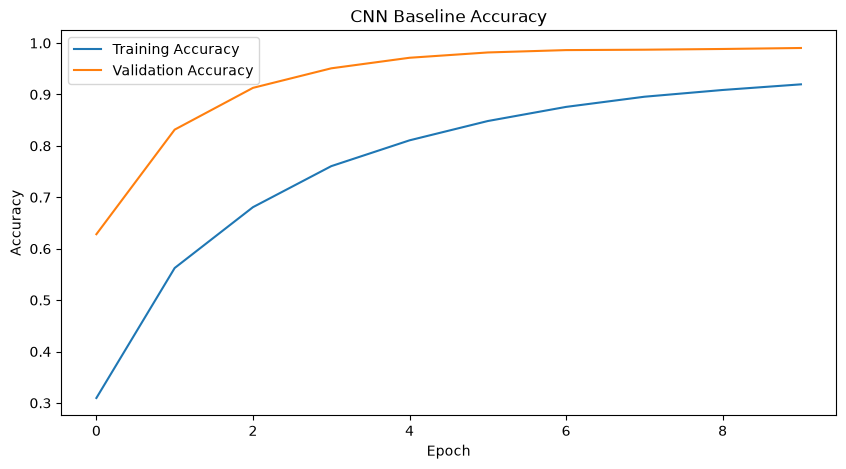

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("CNN Baseline Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

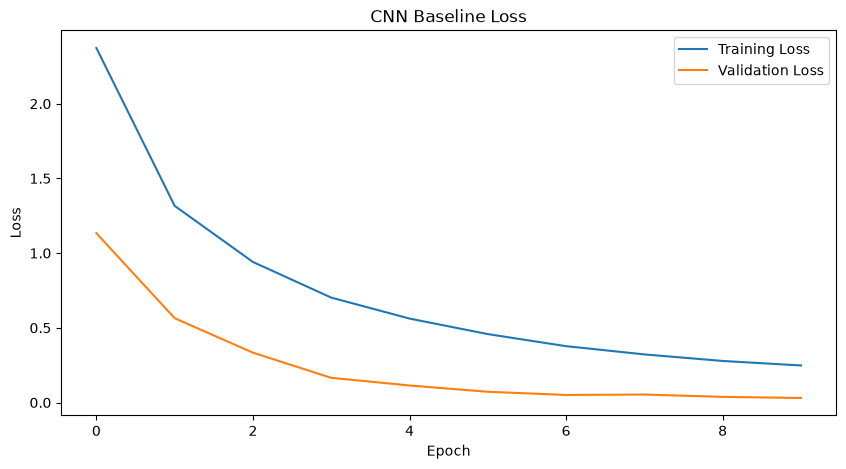

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("CNN Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
y_true = []
y_pred = []
for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("Validation samples:", len(y_true))
print("True classes:", len(np.unique(y_true)))
print("Predicted classes:", len(np.unique(y_pred)))

Validation samples: 7842
True classes: 43
Predicted classes: 43


In [24]:
class_names = [str(i) for i in range(NUM_CLASSES)]
report = classification_report(y_true,y_pred,labels=np.arange(NUM_CLASSES),target_names=class_names,digits=4,zero_division=0)
print(report)

              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9977    0.9932    0.9955       444
           2     0.9887    0.9711    0.9798       450
           3     1.0000    0.9858    0.9929       282
           4     0.9950    1.0000    0.9975       396
           5     0.9531    0.9839    0.9683       372
           6     0.9655    1.0000    0.9825        84
           7     0.9929    0.9688    0.9807       288
           8     0.9790    0.9929    0.9859       282
           9     1.0000    1.0000    1.0000       294
          10     1.0000    1.0000    1.0000       402
          11     0.9962    0.9962    0.9962       264
          12     1.0000    0.9952    0.9976       420
          13     0.9977    1.0000    0.9988       432
          14     1.0000    1.0000    1.0000       156
          15     1.0000    1.0000    1.0000       126
          16     0.9882    1.0000    0.9941        84
          17     1.0000    

In [25]:
macro_f1 = f1_score(y_true,y_pred,average="macro")
weighted_f1 = f1_score(y_true,y_pred,average="weighted")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Macro F1: 0.9868
Weighted F1: 0.9903


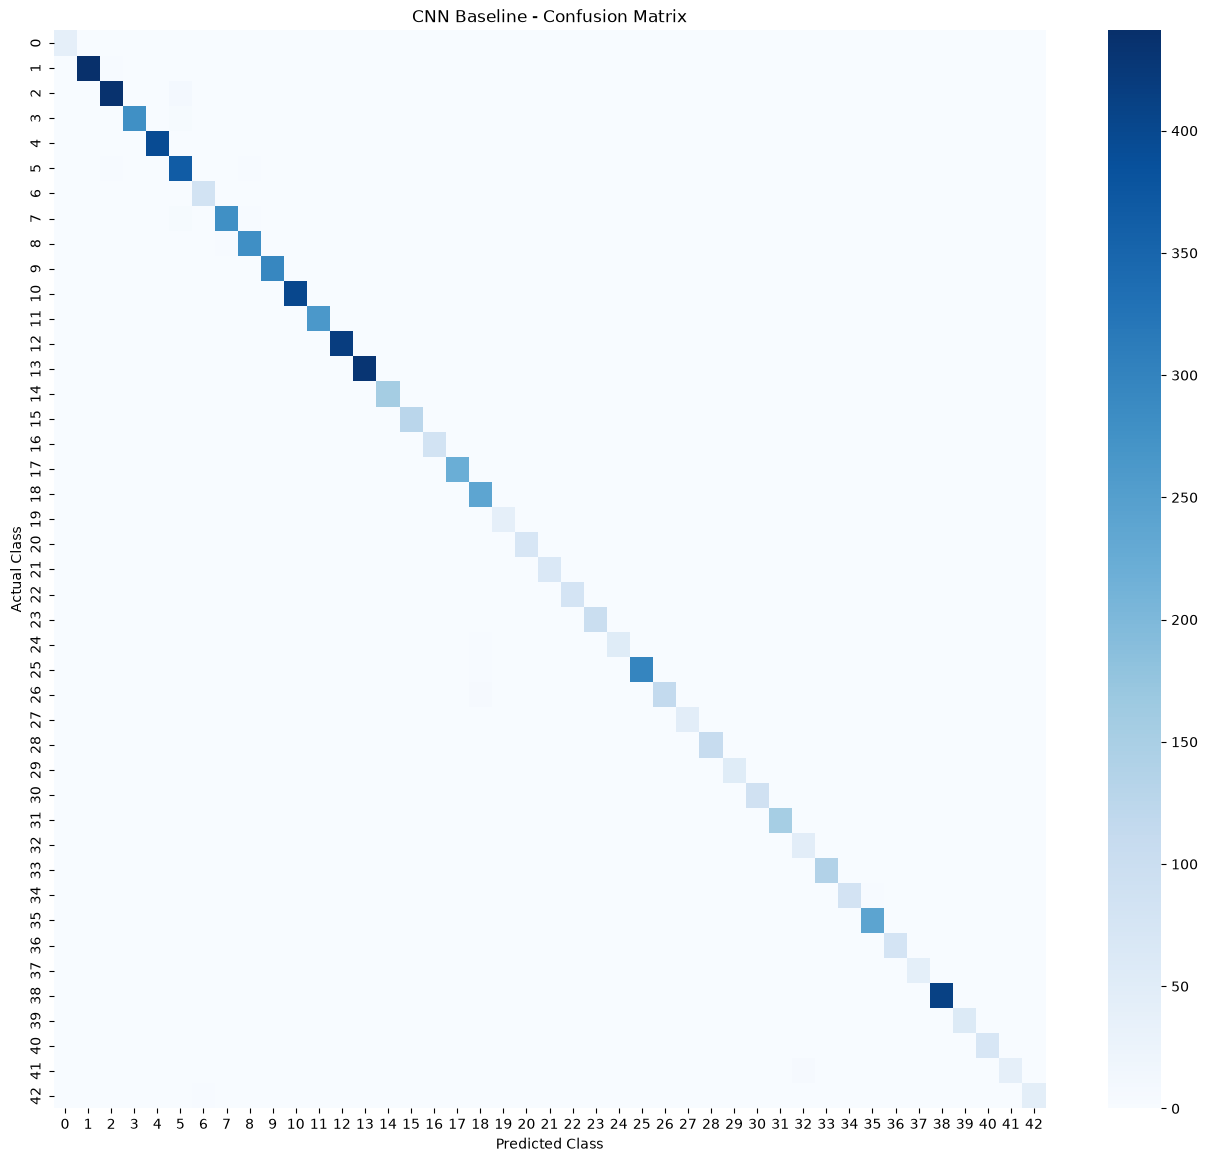

In [26]:
cm = confusion_matrix(y_true,y_pred,labels=np.arange(NUM_CLASSES))
plt.figure(figsize=(16, 14))
sns.heatmap(cm,cmap="Blues",annot=False,fmt="d")
plt.title("CNN Baseline - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [27]:
class_f1 = f1_score(y_true,y_pred,average=None)
class_f1_df = pd.DataFrame({"Class": range(NUM_CLASSES),"F1 Score": class_f1}).sort_values("F1 Score")
print(class_f1_df.head(10))

    Class  F1 Score
41     41  0.921348
32     32  0.941176
42     42  0.958333
5       5  0.968254
26     26  0.974359
18     18  0.975510
34     34  0.975904
0       0  0.976190
19     19  0.976190
2       2  0.979821


In [31]:
model.save(r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\model.keras")

In [33]:
import os

print("Model saved:",os.path.exists(r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\model\model.keras"))

Model saved: True
